In [1]:
import numpy as np
import random

random_state = 3
np.random.seed(random_state)
random.seed(random_state)

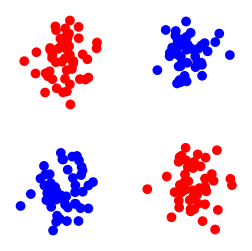

In [2]:
# generate a toy dataset: XOR
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(
    n_samples=200, 
    centers=[[-4,-4], [4,4], [4, -4], [-4, 4]],
    center_box=(-15, 15),
    random_state=random_state
)

# limit to two classes for our purposes
y = np.where((y == 0) | (y == 1), -1, 1)

plt.figure(figsize=(3,3))
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.axis('off');

In [3]:
from vectorgrad.engine import Tensor

# adapted loss functon from micrograd
def loss(batch_size=None):
    
    # inline dataloader
    if batch_size is None:
        Xb, yb = X, y
    else:
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
        
    yb = Tensor(yb.reshape(-1, 1))
    inputs = Tensor(Xb)
    scores = model(inputs)
    
    # hinge loss
    losses = (1 - yb * scores).relu()
    data_loss = losses.mean()
    
    # L2 regularization
    alpha = 1e-4
    reg_loss = Tensor(0.0)
    for p in model.parameters():
        reg_loss = reg_loss + (p * p).sum()
    reg_loss = alpha * reg_loss
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    preds = scores.data > 0
    targets = yb.data > 0
    accuracy = (preds == targets).mean()
    return total_loss, accuracy

In [4]:
from vectorgrad.nn import MLP, ReLU
np.random.seed(random_state)
model = MLP(2, [16, 16, 1])

# optimization step / learning step
lr = 0.01
l2 = 1e-4
for epoch in range(501):

    total_loss, acc = loss()
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    
    # update (sgd)
    for p in model.parameters():
        p.grad += 2 * l2 * p.data
        p.data -= lr * p.grad
        
    if epoch % 50 == 0:
        print(f"step: {epoch} loss {total_loss.data}, accuracy {acc*100}%")

step: 0 loss 1.007858191072066, accuracy 50.0%
step: 50 loss 0.9269930429844075, accuracy 50.0%
step: 100 loss 0.8207310670667188, accuracy 52.0%
step: 150 loss 0.674545371821355, accuracy 67.0%
step: 200 loss 0.46907806810020136, accuracy 87.5%
step: 250 loss 0.20750019122651542, accuracy 99.5%
step: 300 loss 0.03200929737877143, accuracy 100.0%
step: 350 loss 0.013734381944556753, accuracy 100.0%
step: 400 loss 0.00995268734022076, accuracy 100.0%
step: 450 loss 0.008034410438938279, accuracy 100.0%
step: 500 loss 0.006636900457550776, accuracy 100.0%


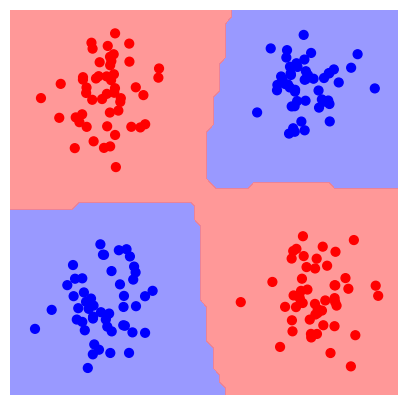

In [5]:
# visualize
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = Tensor(Xmesh)

scores = model(inputs)
Z = np.array(scores.data > 0)
Z = Z.reshape(xx.shape)

fig = plt.figure(figsize=(5,5))
plt.contourf(xx, yy, Z, cmap='bwr', alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap='bwr')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.axis('off');